<a href="https://colab.research.google.com/github/camgenomicmedicine/GMO4/blob/main/GMO4_Advanced_Bioinformatics_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GMO4 Advanced Bioinformatics: NGS data from QC to variant calling

This Google Colab notebook reproduces the four practical sessions:

1. **Practical 2:** read QC and preprocessing with FastQC and Trimmomatic
2. **Practical 3:** alignment to the yeast reference with BWA, samtools and Picard
3. **Practical 4:** BAM refinement, BAM QC and visualisation
4. **Practical 5:** variant calling, comparison and filtering with GATK, FreeBayes and VCFtools

The dataset is whole-genome paired-end resequencing data from *Saccharomyces cerevisiae*:

- Yeast genome: about 12.5 Mbp, 16 chromosomes
- Whole genome sequencing
- Paired-end reads, 108 bp
- One library sequenced across two lanes

## Important Colab notes

- Colab is not a Linux desktop VM, so GUI-only steps such as launching `fastqc &`, `qualimap &` and desktop IGV are replaced with command-line reports and embedded notebook visualisation.
- The software installation cells install the bioinformatics tools into the Colab session. Colab sessions are temporary, so rerun the setup cells whenever the runtime is reset.
- The original course data archive is **not embedded in this notebook**. Put the course archive in Google Drive, or upload it when prompted.

Run the notebook from top to bottom.


## 0. Install command-line tools

This cell installs the tools used across the four practicals. It uses `micromamba` to create an isolated environment under `/content/bioinfo_env`.

Installed tools include:

- `fastqc`
- `trimmomatic`
- `bwa`
- `samtools`
- `picard`
- `gatk4`
- `freebayes`
- `vcftools`
- `qualimap`
- `multiqc`
- `r-base`
- `igv-notebook` for embedded IGV-style visualisation


In [ ]:
%%bash
set -euo pipefail

mkdir -p /content/bin

if [ ! -x /content/bin/micromamba ]; then
  echo "Downloading micromamba..."
  curl -Ls https://micro.mamba.pm/api/micromamba/linux-64/latest \
    | tar -xvj -C /content/bin --strip-components=1 bin/micromamba
else
  echo "micromamba is already installed."
fi

export MAMBA_ROOT_PREFIX=/content/micromamba
ENV_PREFIX=/content/bioinfo_env

if [ ! -x "$ENV_PREFIX/bin/samtools" ]; then
  echo "Creating bioinformatics environment..."
  /content/bin/micromamba create -y -p "$ENV_PREFIX" \
    -c conda-forge -c bioconda \
    python=3.11 \
    fastqc trimmomatic bwa samtools picard gatk4 freebayes vcftools qualimap multiqc r-base openjdk
else
  echo "Bioinformatics environment already exists."
fi

"$ENV_PREFIX/bin/pip" install -q igv-notebook

echo "Setup complete."


bin/micromamba
Creating bioinformatics environment...


Transaction

  Prefix: /content/bioinfo_env

  Updating specs:

   - python=3.11
   - fastqc
   - trimmomatic
   - bwa
   - samtools
   - picard
   - gatk4
   - freebayes
   - vcftools
   - qualimap
   - multiqc
   - r-base
   - openjdk


  Package                                        Version  Build                 Channel          Size
───────────────────────────────────────────────────────────────────────────────────────────────────────
  Install:
───────────────────────────────────────────────────────────────────────────────────────────────────────

  + _openmp_mutex                                    4.5  20_gnu                conda-forge      29kB
  + _python_abi3_support                             1.0  hd8ed1ab_2            conda-forge       8kB
  + _r-mutex                                       1.0.1  anacondar_1           conda-forge       4kB
  + alsa-lib                                    1.2.15.3  hb03c661_0         

In [ ]:
# Put the conda environment on PATH for Python cells and shell commands.
import os
ENV_PREFIX = "/content/bioinfo_env"
os.environ["PATH"] = f"{ENV_PREFIX}/bin:/content/bin:" + os.environ["PATH"]

print("PATH begins with:", os.environ["PATH"].split(":")[:3])


PATH begins with: ['/content/bioinfo_env/bin', '/content/bin', '/opt/bin']


In [ ]:
%%bash
set -euo pipefail
export PATH="/content/bioinfo_env/bin:/content/bin:$PATH"

echo "Checking installed tools..."
for tool in fastqc trimmomatic bwa samtools picard gatk freebayes vcftools qualimap multiqc; do
  printf "%-12s" "$tool"
  command -v "$tool"
done

echo
fastqc --version || true
samtools --version | head -n 1
bwa 2>&1 | head -n 3 || true
gatk --version | head -n 2 || true
freebayes --version || true
vcftools --version || true
multiqc --version || true


Checking installed tools...
fastqc      /content/bioinfo_env/bin/fastqc
trimmomatic /content/bioinfo_env/bin/trimmomatic
bwa         /content/bioinfo_env/bin/bwa
samtools    /content/bioinfo_env/bin/samtools
picard      /content/bioinfo_env/bin/picard
gatk        /content/bioinfo_env/bin/gatk
freebayes   /content/bioinfo_env/bin/freebayes
vcftools    /content/bioinfo_env/bin/vcftools
qualimap    /content/bioinfo_env/bin/qualimap
multiqc     /content/bioinfo_env/bin/multiqc

FastQC v0.12.1
samtools 1.23.1

Program: bwa (alignment via Burrows-Wheeler transformation)
Version: 0.7.19-r1273
The Genome Analysis Toolkit (GATK) v4.6.2.0
HTSJDK Version: 4.2.0
version:  v1.3.10
VCFtools (0.1.17)
multiqc, version 1.34


Using GATK jar /content/bioinfo_env/share/gatk4-4.6.2.0-0/gatk-package-4.6.2.0-local.jar
Running:
    java -Dsamjdk.use_async_io_read_samtools=false -Dsamjdk.use_async_io_write_samtools=true -Dsamjdk.use_async_io_write_tribble=false -Dsamjdk.compression_level=2 -jar /content/bioinfo_env/share/gatk4-4.6.2.0-0/gatk-package-4.6.2.0-local.jar --version


## 1. Prepare the course data

The practical manuals make use of a tar archive called `GM04_AdvBioinfo_NGS_April2026.tar` containing:

- `lane1/` and `lane2/` FASTQ files
- the yeast reference genome `Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa`
- the adapter/primer FASTA file `primers_adapters.fa`

Please  either upload the archive to colab using the file manager, or upload the tar file when prompted when the next cell is run.

After extraction, the notebook automatically finds the reference FASTA and sets `WORKDIR`.


In [ ]:
from pathlib import Path
import os, tarfile

# Students should upload the GMO4 course data archive into /content before running this cell.
# In Colab, either use the file browser on the left, or run the upload prompt below.
os.chdir("/content")

candidate_names = [
    # Current/recommended names
    "GM04_AdvBioinfo_NGS_April2026.tar",
    "GM04_AdvBioinfo_NGS_Mar2026.tar",
    "GM04_AdvBioinfo_NGS.tar",

    # Names used in earlier versions of the practical
    "GM04_AdvBioinfo_NGS_April2021.tar",
    "GM04_AdvBioinfo_NGS_Mar2020.tar",
]

archive_path = None

# 1. Look for one of the expected archive names in /content.
for name in candidate_names:
    p = Path("/content") / name
    if p.exists():
        archive_path = p
        break

# 2. If no expected name is found, look for a single tar/tar.gz/tgz file in /content.
if archive_path is None:
    archives = sorted(
        list(Path("/content").glob("*.tar")) +
        list(Path("/content").glob("*.tar.gz")) +
        list(Path("/content").glob("*.tgz"))
    )

    if len(archives) == 1:
        archive_path = archives[0]
    elif len(archives) > 1:
        raise FileNotFoundError(
            "More than one archive was found in /content:\n"
            + "\n".join(f" - {p.name}" for p in archives)
            + "\nPlease keep only the GMO4 course data archive in /content, then rerun this cell."
        )

# 3. If no archive is present, show a Colab upload button.
#    files.upload() saves the uploaded file into the current directory, which we set to /content above.
if archive_path is None:
    try:
        from google.colab import files
        print("Please upload the GMO4 course data .tar, .tar.gz, or .tgz archive.")
        uploaded = files.upload()

        uploaded_archives = [
            Path("/content") / name
            for name in uploaded
            if name.endswith((".tar", ".tar.gz", ".tgz"))
        ]

        if len(uploaded_archives) == 1:
            archive_path = uploaded_archives[0]
        elif len(uploaded_archives) > 1:
            raise FileNotFoundError(
                "More than one archive was uploaded. Please upload only the GMO4 course data archive."
            )
    except ImportError:
        pass

if archive_path is None or not archive_path.exists():
    raise FileNotFoundError(
        "No course data archive was found. Upload the GMO4 .tar, .tar.gz, or .tgz archive "
        "to /content, then rerun this cell."
    )

print("Using archive:", archive_path)

extract_dir = Path("/content/gmo4_data")
extract_dir.mkdir(exist_ok=True)

def safe_extract(tar, path):
    """Extract tar archive while preventing path traversal outside the target directory."""
    dest = path.resolve()
    for member in tar.getmembers():
        target = (path / member.name).resolve()
        try:
            target.relative_to(dest)
        except ValueError:
            raise RuntimeError(f"Unsafe path in archive: {member.name}")
    tar.extractall(path)

marker = extract_dir / ".extracted"
marker_text = str(archive_path.resolve())

if not marker.exists() or marker.read_text().strip() != marker_text:
    print("Extracting archive...")
    with tarfile.open(archive_path, "r:*") as tar:
        safe_extract(tar, extract_dir)
    marker.write_text(marker_text)
else:
    print("Archive already extracted.")

# Find the reference FASTA and use its directory as the working directory.
refs = list(extract_dir.rglob("Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa"))
if not refs:
    raise FileNotFoundError(
        "Could not find Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa "
        "inside the archive. Check that the correct course data archive was uploaded."
    )

WORKDIR = refs[0].parent
os.environ["WORKDIR"] = str(WORKDIR)
os.chdir(WORKDIR)

print("WORKDIR:", WORKDIR)
print("Files and folders at WORKDIR:")
for p in sorted(WORKDIR.iterdir()):
    print(" -", p.name)

Using archive: /content/GM04_AdvBioinfo_NGS_April2026.tar
Archive already extracted.
WORKDIR: /content/gmo4_data/VariantCalling
Files and folders at WORKDIR:
 - Saccharomyces_cerevisiae.EF4.68.dna.toplevel.dict
 - Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa
 - Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa.amb
 - Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa.ann
 - Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa.bwt
 - Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa.fai
 - Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa.pac
 - Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa.sa
 - compare.diff.sites_in_files
 - compare.vcftools.log
 - compare_filtered.diff.sites_in_files
 - compare_filtered.vcftools.log
 - dupl_metrics.txt
 - fastqc_raw
 - fastqc_trimmed
 - freebayes_QUAL_100_variants.tsv
 - freebayes_variants_I_flt2.recode.vcf
 - freebayes_variants_I_flt2_nomissing.recode.vcf
 - freebayes_variants_raw_I_bq20_mq50.vcf
 - freebayes_variants_raw_I_bq20_mq50_SNP.vcf
 - freebayes_var

In [ ]:
%%bash
set -euo pipefail
cd "$WORKDIR"

echo "Directory tree, first 80 files:"
find . -maxdepth 3 -type f | sort | head -n 80

echo
echo "Expected key files:"
ls -lh Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa primers_adapters.fa
ls -lh lane1 lane2


Directory tree, first 80 files:
./lane1/s-7-1.fastq
./lane1/._s-7-1.fastq
./lane1/s-7-2.fastq
./lane1/._s-7-2.fastq
./lane2/s-7-1.fastq
./lane2/._s-7-1.fastq
./lane2/s-7-2.fastq
./lane2/._s-7-2.fastq
./mito.intervals
./primers_adapters.fa
./Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa

Expected key files:
-rw-r--r-- 1 1000 1000 537 Aug 16  2019 primers_adapters.fa
-rw-r--r-- 1 1000 1000 12M Nov  2  2017 Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa
lane1:
total 96M
-rw-r--r-- 1 1000 1000 48M Nov  2  2017 s-7-1.fastq
-rw-r--r-- 1 1000 1000 48M Nov  2  2017 s-7-2.fastq

lane2:
total 58M
-rw-r--r-- 1 1000 1000 29M Nov  2  2017 s-7-1.fastq
-rw-r--r-- 1 1000 1000 29M Nov  2  2017 s-7-2.fastq


## Practical 2: Data QC and preprocessing

### Learning objectives

By the end of this section you should be able to:

- recognise FASTQ read data
- assess paired-end data with FastQC
- remove adapter and primer contamination with Trimmomatic
- trim low-quality bases and reads with Trimmomatic
- compare pre- and post-trimming FastQC reports


### 2.1 Inspect the FASTQ files

The dataset contains two lanes of paired-end sequencing. Each lane has read 1 and read 2 FASTQ files.

Questions to answer:

- **Q1.** Which files are read 1 and which are read 2?
- **Q2.** What does the Unix command `tail` do, based on what `head` does?


In [ ]:
%%bash
set -euo pipefail
cd "$WORKDIR"

echo "FASTQ files:"
find lane1 lane2 -maxdepth 2 -type f -name "*.fastq" -print | sort

echo
echo "First 12 lines of lane1 read 1:"
head -n 12 lane1/s-7-1.fastq

echo
echo "Last 8 lines of lane1 read 1:"
tail -n 8 lane1/s-7-1.fastq


FASTQ files:
lane1/s-7-1.fastq
lane1/._s-7-1.fastq
lane1/s-7-2.fastq
lane1/._s-7-2.fastq
lane2/s-7-1.fastq
lane2/._s-7-1.fastq
lane2/s-7-2.fastq
lane2/._s-7-2.fastq

First 12 lines of lane1 read 1:
@IL29_4505:7:24:8932:6562#2/1
TAACGGTGGGTGAGTGGTAGTAAGTAGAGGGATGGATGGTGGTTCGGAGTGGTATGGTTGAATGGGACAGGGTAACGAGTGGAGAGTAGGGTAATGGAGGGTAAGTTC
+
CDDCDDABBBABABABB@BCACBDABCBBAB@BBCABBBABB?CBCCABABBABBBBABA?ACBAAAAA?BB;BCAABA7AA?B?A??AAA>?A:AA?AA?%?AA@=9
@IL29_4505:7:15:7929:11873#2/1
TTAACGTTTCAATATGGTAGGTAGAACAACAGTACAGTGAGTGGGACATGGTGGATGGTAAAAGAATGGTAGGGTAAGTGGCAGTGGGGTTGGATATGGGTAATTGGA
+
DDDDDDCDDCDDDDCCDBDDDACCCCCCCDCCBCDCCBCBCACCCBCBCCCACCACCCAAABABAABBC?ABBA=BBA?BAAAB?BABA7AAB?AAAAA@:A?AA?B-
@IL29_4505:7:109:18599:8300#2/1
CTTACCCTCCATTACCCTACCTCCACTCGTTACCCTGTCCCATTCAACCATACCACTCCGAACCACCATCCATCCCTCTACTTACTACCACTCACCCACCGTTACCCT
+
D?BDCABBBABBDACCBBDCDCBBBBABBBCDABBBABBBBBCBA@ABCBCBB@BB0=BB4><B:BABAABBABA@AB=BB?ACBABA?AB;BBBABBBB'0=CB9<9

Last 8 lines of lane1 read 1:
@IL29_4505:7:120:1

### 2.2 Run FastQC on the raw FASTQ files

FastQC produces a quality report for each input FASTQ file. MultiQC then aggregates the reports into a single HTML file.


In [ ]:
%%bash
set -euo pipefail
export PATH="/content/bioinfo_env/bin:/content/bin:$PATH"
cd "$WORKDIR"

mkdir -p fastqc_raw

fastqc -t 2 -o fastqc_raw \
  lane1/s-7-1.fastq lane1/s-7-2.fastq \
  lane2/s-7-1.fastq lane2/s-7-2.fastq

multiqc -f fastqc_raw -n multiqc_raw.html -o .


null
null
null
null
Analysis complete for s-7-1.fastq
Analysis complete for s-7-2.fastq
Analysis complete for s-7-1.fastq
Analysis complete for s-7-2.fastq


Started analysis of s-7-1.fastq
Started analysis of s-7-2.fastq
Approx 5% complete for s-7-1.fastq
Approx 5% complete for s-7-2.fastq
Approx 10% complete for s-7-1.fastq
Approx 10% complete for s-7-2.fastq
Approx 15% complete for s-7-1.fastq
Approx 15% complete for s-7-2.fastq
Approx 20% complete for s-7-1.fastq
Approx 20% complete for s-7-2.fastq
Approx 25% complete for s-7-1.fastq
Approx 25% complete for s-7-2.fastq
Approx 30% complete for s-7-1.fastq
Approx 30% complete for s-7-2.fastq
Approx 35% complete for s-7-1.fastq
Approx 35% complete for s-7-2.fastq
Approx 40% complete for s-7-1.fastq
Approx 40% complete for s-7-2.fastq
Approx 45% complete for s-7-1.fastq
Approx 45% complete for s-7-2.fastq
Approx 50% complete for s-7-1.fastq
Approx 50% complete for s-7-2.fastq
Approx 55% complete for s-7-1.fastq
Approx 60% complete for s-7-1.fastq
Approx 55% complete for s-7-2.fastq
Approx 65% complete for s-7-1.fastq
Approx 60% complete for s-7-2.fastq
Approx 70% complete for s-7-1.fastq
Ap

In [ ]:
from IPython.display import HTML, display
from pathlib import Path
display(HTML(Path(WORKDIR, "multiqc_raw.html").read_text(errors="ignore")))


### 2.3 Summarise key FastQC fields

Use the table below to help answer the practical questions.

Questions to answer:

- **Q3.** What is the total number of sequences in each paired-end FASTQ file? Do both lanes provide the same sequencing output?
- **Q4.** What type of quality-score encoding is used?
- **Q5.** What is the read length? Is it the same for both lanes?
- **Q6.** How does quality compare between read 1 and read 2?
- **Q7.** Are there any issues with the data?


In [ ]:
import zipfile
from pathlib import Path
import pandas as pd
from IPython.display import display

def parse_fastqc_data(zip_path):
    zip_path = Path(zip_path)
    data_file = None
    with zipfile.ZipFile(zip_path) as z:
        for name in z.namelist():
            if name.endswith("fastqc_data.txt"):
                data_file = name
                break
        text = z.read(data_file).decode()
    fields = {}
    in_basic = False
    for line in text.splitlines():
        if line.startswith(">>Basic Statistics"):
            in_basic = True
            continue
        if in_basic and line.startswith(">>END_MODULE"):
            break
        if in_basic and "\t" in line:
            k, v = line.split("\t", 1)
            fields[k] = v
    return fields

rows = []
for z in sorted(Path(WORKDIR, "fastqc_raw").glob("*_fastqc.zip")):
    fields = parse_fastqc_data(z)
    rows.append({
        "report": z.name,
        "total_sequences": fields.get("Total Sequences"),
        "sequence_length": fields.get("Sequence length"),
        "encoding": fields.get("Encoding"),
        "%GC": fields.get("%GC"),
    })

raw_fastqc_summary = pd.DataFrame(rows)
display(raw_fastqc_summary)


,report,total_sequences,sequence_length,encoding,%GC
0,s-7-1_fastqc.zip,119064,108,Sanger / Illumina 1.9,37
1,s-7-2_fastqc.zip,119064,108,Sanger / Illumina 1.9,39


### 2.4 Remove primer and adapter sequences with Trimmomatic

The FastQC "Overrepresented sequences" module indicates whether many reads contain adapter or primer sequence. The course data includes a prepared `primers_adapters.fa` file.

The first Trimmomatic pass removes adapter/primer contamination while keeping read pairs whenever both reads survive.


In [ ]:
%%bash
set -euo pipefail
export PATH="/content/bioinfo_env/bin:/content/bin:$PATH"
cd "$WORKDIR"

trimmomatic PE -phred33 -threads 2 -trimlog \
  lane1/trimm_logfile lane1/s-7-1.fastq lane1/s-7-2.fastq \
  lane1/s-7-1.paired.fastq lane1/s-7-1.unpaired.fastq \
  lane1/s-7-2.paired.fastq lane1/s-7-2.unpaired.fastq \
  ILLUMINACLIP:primers_adapters.fa:2:30:10 MINLEN:36

trimmomatic PE -phred33 -threads 2 -trimlog \
  lane2/trimm_logfile lane2/s-7-1.fastq lane2/s-7-2.fastq \
  lane2/s-7-1.paired.fastq lane2/s-7-1.unpaired.fastq \
  lane2/s-7-2.paired.fastq lane2/s-7-2.unpaired.fastq \
  ILLUMINACLIP:primers_adapters.fa:2:30:10 MINLEN:36


TrimmomaticPE: Started with arguments:
 -phred33 -threads 2 -trimlog lane1/trimm_logfile lane1/s-7-1.fastq lane1/s-7-2.fastq lane1/s-7-1.paired.fastq lane1/s-7-1.unpaired.fastq lane1/s-7-2.paired.fastq lane1/s-7-2.unpaired.fastq ILLUMINACLIP:primers_adapters.fa:2:30:10 MINLEN:36
ILLUMINACLIP: Using adapter file from current working directory: /content/gmo4_data/VariantCalling/primers_adapters.fa
Using Long Clipping Sequence: 'GAACTCCAGTCACTAGCTTATCTCGTATGCCGTCTTCTGCTTG'
Using Long Clipping Sequence: 'CAAGCAGAAGACGGCATACGAGATAAGCTAGTGACTGGAGTTC'
Using Long Clipping Sequence: 'AGATCGGAAGAGCGGTTCAGCAGGAATGCCGAGACCGATCTCGTATGCCGTCTTCTGCTTG'
Using Long Clipping Sequence: 'AGATCGGAAGAGCGGTTCAGCAGGAATGCCGAG'
Using Long Clipping Sequence: 'CTCGGCATTCCTGCTGAACCGCTCTTCCGATCT'
Using Long Clipping Sequence: 'AGATCGGAAGAGCGTCGTGTAGGGAAAGAGTGTAGATCTCGGTGGTCGCCGTATCATT'
Using Long Clipping Sequence: 'AATGATACGGCGACCACCGAGATCTACACTCTTTCCCTACACGACGCTCTTCCGATCT'
Using Long Clipping Sequence: 'CAAGCAGAAG

Questions to answer:

- **Q8.** According to the Trimmomatic output, what number and percentage of read pairs had "both survived" adapter trimming?
- **Q9.** How many read pairs were trimmed and then deleted in this step?

Tip: the Trimmomatic summary is printed in the cell output above. If you rerun cells later and lose the output, inspect the `trimm_logfile` files or rerun this step.


### 2.5 Trim low-quality bases

The second Trimmomatic pass removes low-quality bases from the ends of reads and uses sliding-window trimming.


In [ ]:
%%bash
set -euo pipefail
export PATH="/content/bioinfo_env/bin:/content/bin:$PATH"
cd "$WORKDIR"

trimmomatic PE -phred33 -threads 2 -trimlog \
  lane1/trimm_logfile2 \
  lane1/s-7-1.paired.fastq lane1/s-7-2.paired.fastq \
  lane1/s-7-1.trim.paired.fastq lane1/s-7-1.trim.unpaired.fastq \
  lane1/s-7-2.trim.paired.fastq lane1/s-7-2.trim.unpaired.fastq \
  LEADING:3 TRAILING:3 SLIDINGWINDOW:4:15 MINLEN:36

trimmomatic PE -phred33 -threads 2 -trimlog \
  lane2/trimm_logfile2 \
  lane2/s-7-1.paired.fastq lane2/s-7-2.paired.fastq \
  lane2/s-7-1.trim.paired.fastq lane2/s-7-1.trim.unpaired.fastq \
  lane2/s-7-2.trim.paired.fastq lane2/s-7-2.trim.unpaired.fastq \
  LEADING:3 TRAILING:3 SLIDINGWINDOW:4:15 MINLEN:36


TrimmomaticPE: Started with arguments:
 -phred33 -threads 2 -trimlog lane1/trimm_logfile2 lane1/s-7-1.paired.fastq lane1/s-7-2.paired.fastq lane1/s-7-1.trim.paired.fastq lane1/s-7-1.trim.unpaired.fastq lane1/s-7-2.trim.paired.fastq lane1/s-7-2.trim.unpaired.fastq LEADING:3 TRAILING:3 SLIDINGWINDOW:4:15 MINLEN:36
Input Read Pairs: 170800 Both Surviving: 156349 (91.54%) Forward Only Surviving: 13287 (7.78%) Reverse Only Surviving: 677 (0.40%) Dropped: 487 (0.29%)
TrimmomaticPE: Completed successfully
TrimmomaticPE: Started with arguments:
 -phred33 -threads 2 -trimlog lane2/trimm_logfile2 lane2/s-7-1.paired.fastq lane2/s-7-2.paired.fastq lane2/s-7-1.trim.paired.fastq lane2/s-7-1.trim.unpaired.fastq lane2/s-7-2.trim.paired.fastq lane2/s-7-2.trim.unpaired.fastq LEADING:3 TRAILING:3 SLIDINGWINDOW:4:15 MINLEN:36
Input Read Pairs: 102263 Both Surviving: 93597 (91.53%) Forward Only Surviving: 7995 (7.82%) Reverse Only Surviving: 399 (0.39%) Dropped: 272 (0.27%)
TrimmomaticPE: Completed success

### 2.6 Reassess trimmed reads with FastQC

Run FastQC again on the final paired FASTQ files and compare raw versus trimmed data.


In [ ]:
%%bash
set -euo pipefail
export PATH="/content/bioinfo_env/bin:/content/bin:$PATH"
cd "$WORKDIR"

mkdir -p fastqc_trimmed

fastqc -t 2 -o fastqc_trimmed \
  lane1/s-7-1.trim.paired.fastq lane1/s-7-2.trim.paired.fastq \
  lane2/s-7-1.trim.paired.fastq lane2/s-7-2.trim.paired.fastq

multiqc -f fastqc_raw fastqc_trimmed -n multiqc_raw_vs_trimmed.html -o .


null
null
null
null
Analysis complete for s-7-2.trim.paired.fastq
Analysis complete for s-7-1.trim.paired.fastq
Analysis complete for s-7-1.trim.paired.fastq
Analysis complete for s-7-2.trim.paired.fastq


Started analysis of s-7-1.trim.paired.fastq
Started analysis of s-7-2.trim.paired.fastq
Approx 5% complete for s-7-1.trim.paired.fastq
Approx 5% complete for s-7-2.trim.paired.fastq
Approx 10% complete for s-7-1.trim.paired.fastq
Approx 10% complete for s-7-2.trim.paired.fastq
Approx 15% complete for s-7-1.trim.paired.fastq
Approx 15% complete for s-7-2.trim.paired.fastq
Approx 20% complete for s-7-1.trim.paired.fastq
Approx 20% complete for s-7-2.trim.paired.fastq
Approx 25% complete for s-7-2.trim.paired.fastq
Approx 25% complete for s-7-1.trim.paired.fastq
Approx 30% complete for s-7-2.trim.paired.fastq
Approx 30% complete for s-7-1.trim.paired.fastq
Approx 35% complete for s-7-2.trim.paired.fastq
Approx 35% complete for s-7-1.trim.paired.fastq
Approx 40% complete for s-7-2.trim.paired.fastq
Approx 40% complete for s-7-1.trim.paired.fastq
Approx 45% complete for s-7-2.trim.paired.fastq
Approx 45% complete for s-7-1.trim.paired.fastq
Approx 50% complete for s-7-2.trim.paired.fastq
Ap

In [ ]:
from IPython.display import HTML, display
from pathlib import Path
display(HTML(Path(WORKDIR, "multiqc_raw_vs_trimmed.html").read_text(errors="ignore")))


In [ ]:
rows = []
for label, folder in [("raw", "fastqc_raw"), ("trimmed", "fastqc_trimmed")]:
    for z in sorted(Path(WORKDIR, folder).glob("*_fastqc.zip")):
        fields = parse_fastqc_data(z)
        rows.append({
            "stage": label,
            "report": z.name,
            "total_sequences": int(fields.get("Total Sequences", "0")),
            "sequence_length": fields.get("Sequence length"),
            "encoding": fields.get("Encoding"),
            "%GC": fields.get("%GC"),
        })

display(pd.DataFrame(rows))


,stage,report,total_sequences,sequence_length,encoding,%GC
0,raw,s-7-1_fastqc.zip,119064,108,Sanger / Illumina 1.9,37
1,raw,s-7-2_fastqc.zip,119064,108,Sanger / Illumina 1.9,39
2,trimmed,s-7-1.trim.paired_fastqc.zip,93597,36-108,Sanger / Illumina 1.9,36
3,trimmed,s-7-2.trim.paired_fastqc.zip,93597,36-108,Sanger / Illumina 1.9,36


### Optional extension: try different quality cutoffs

To explore the effect of stringency, rerun the quality-trimming command with different values in `SLIDINGWINDOW:4:15`, such as `SLIDINGWINDOW:4:5`, `SLIDINGWINDOW:4:20` or `SLIDINGWINDOW:4:30`.

Remember to change output filenames before rerunning so that you do not overwrite the main practical outputs.


## Practical 3: Alignment to a reference genome

### Learning objectives

By the end of this section you should be able to:

- create reference genome indices for samtools, BWA and Picard
- align paired-end reads to the reference with `bwa mem`
- convert SAM to BAM
- sort and index BAM files with samtools
- merge lane-level BAM files into a library-level BAM


### 3.1 Create reference genome index and dictionary files

Index files allow tools to access large reference and alignment files efficiently.


In [ ]:
%%bash
set -euo pipefail
export PATH="/content/bioinfo_env/bin:/content/bin:$PATH"
cd "$WORKDIR"

REF="Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa"
DICT="${REF%.fa}.dict"

samtools faidx "$REF"
bwa index -a is "$REF"
picard CreateSequenceDictionary R="$REF" O="$DICT"

echo
echo "Reference-related files:"
ls -lh "$REF"* "${REF%.fa}.dict"



Reference-related files:
-rw-r--r-- 1 root root 2.5K Apr 28 20:52 Saccharomyces_cerevisiae.EF4.68.dna.toplevel.dict
-rw-r--r-- 1 1000 1000  12M Nov  2  2017 Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa
-rw-r--r-- 1 root root   14 Apr 28 20:52 Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa.amb
-rw-r--r-- 1 root root 1.2K Apr 28 20:52 Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa.ann
-rw-r--r-- 1 root root  12M Apr 28 20:52 Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa.bwt
-rw-r--r-- 1 root root  415 Apr 28 20:51 Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa.fai
-rw-r--r-- 1 root root 2.9M Apr 28 20:52 Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa.pac
-rw-r--r-- 1 root root 5.8M Apr 28 20:52 Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa.sa


[bwa_index] Pack FASTA... 0.10 sec
[bwa_index] Construct BWT for the packed sequence...
[bwa_index] 8.94 seconds elapse.
[bwa_index] Update BWT... 0.11 sec
[bwa_index] Pack forward-only FASTA... 0.09 sec
[bwa_index] Construct SA from BWT and Occ... 5.58 sec
[main] Version: 0.7.19-r1273
[main] CMD: bwa index -a is Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa
[main] Real time: 15.015 sec; CPU: 14.820 sec
INFO	2026-04-28 20:52:10	CreateSequenceDictionary	

********** NOTE: Picard's command line syntax is changing.
**********
********** For more information, please see:
********** 
https://github.com/broadinstitute/picard/wiki/Command-Line-Syntax-Transition-For-Users-(Pre-Transition)
**********
********** The command line looks like this in the new syntax:
**********
**********    CreateSequenceDictionary -R Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa -O Saccharomyces_cerevisiae.EF4.68.dna.toplevel.dict
**********


20:52:10.248 INFO  NativeLibraryLoader - Loading libgkl_compression

Question to answer:

- **Q1.** What file extensions were created by samtools, BWA and Picard?


### 3.2 Align lane 1 reads with BWA-MEM

The read group (`-R`) records the lane and sample metadata in the BAM header.


In [ ]:
%%bash
set -euo pipefail
export PATH="/content/bioinfo_env/bin:/content/bin:$PATH"
cd "$WORKDIR"

REF="Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa"

bwa mem -t 2 \
  -R '@RG\tID:1\tLB:library\tPL:Illumina\tPU:lane1\tSM:yeast' \
  "$REF" \
  lane1/s-7-1.trim.paired.fastq lane1/s-7-2.trim.paired.fastq \
  > lane1.sam

samtools view -@ 2 -b lane1.sam -o lane1.bam
samtools sort -@ 2 lane1.bam -o lane1_sorted.bam
samtools index lane1_sorted.bam

ls -lh lane1.sam lane1.bam lane1_sorted.bam lane1_sorted.bam.bai


-rw-r--r-- 1 root root  26M Apr 28 20:52 lane1.bam
-rw-r--r-- 1 root root 101M Apr 28 20:52 lane1.sam
-rw-r--r-- 1 root root  26M Apr 28 20:52 lane1_sorted.bam
-rw-r--r-- 1 root root  11K Apr 28 20:52 lane1_sorted.bam.bai


[M::bwa_idx_load_from_disk] read 0 ALT contigs
[M::process] read 188682 sequences (20000111 bp)...
[M::process] read 124016 sequences (13125231 bp)...
[M::mem_pestat] # candidate unique pairs for (FF, FR, RF, RR): (170, 81778, 3, 2)
[M::mem_pestat] analyzing insert size distribution for orientation FF...
[M::mem_pestat] (25, 50, 75) percentile: (90, 132, 169)
[M::mem_pestat] low and high boundaries for computing mean and std.dev: (1, 327)
[M::mem_pestat] mean and std.dev: (131.64, 61.69)
[M::mem_pestat] low and high boundaries for proper pairs: (1, 406)
[M::mem_pestat] analyzing insert size distribution for orientation FR...
[M::mem_pestat] (25, 50, 75) percentile: (260, 283, 306)
[M::mem_pestat] low and high boundaries for computing mean and std.dev: (168, 398)
[M::mem_pestat] mean and std.dev: (282.55, 36.12)
[M::mem_pestat] low and high boundaries for proper pairs: (122, 444)
[M::mem_pestat] skip orientation RF as there are not enough pairs
[M::mem_pestat] skip orientation RR as the

Questions to answer:

- **Q2.** What extension does the BAM index file have?
- **Q3.** How many chromosomes are present in the BAM header, and which SAM version is reported?
- **Q4.** Can you see the read group line?
- **Q5.** What appears after the SAM header if you view the SAM file with `more`, `less`, or `head`?


In [ ]:
%%bash
set -euo pipefail
export PATH="/content/bioinfo_env/bin:/content/bin:$PATH"
cd "$WORKDIR"

echo "BAM header, first 60 lines:"
samtools view -H lane1_sorted.bam | sed -n '1,60p'

echo
echo "Number of @SQ sequence/chromosome lines:"
samtools view -H lane1_sorted.bam | grep -c '^@SQ'

echo
echo "Read group line:"
samtools view -H lane1_sorted.bam | grep '^@RG' || true

echo
echo "First non-header alignments in lane1.sam:"
awk '!/^@/ {print; n++; if (n==5) exit}' lane1.sam

BAM header, first 60 lines:
@HD	VN:1.5	SO:coordinate
@SQ	SN:I	LN:230218
@SQ	SN:II	LN:813184
@SQ	SN:III	LN:316620
@SQ	SN:IV	LN:1531933
@SQ	SN:IX	LN:439888
@SQ	SN:Mito	LN:85779
@SQ	SN:V	LN:576874
@SQ	SN:VI	LN:270161
@SQ	SN:VII	LN:1090940
@SQ	SN:VIII	LN:562643
@SQ	SN:X	LN:745751
@SQ	SN:XI	LN:666816
@SQ	SN:XII	LN:1078177
@SQ	SN:XIII	LN:924431
@SQ	SN:XIV	LN:784333
@SQ	SN:XV	LN:1091291
@SQ	SN:XVI	LN:948066
@RG	ID:1	LB:library	PL:Illumina	PU:lane1	SM:yeast
@PG	ID:bwa	PN:bwa	VN:0.7.19-r1273	CL:bwa mem -t 2 -R @RG\tID:1\tLB:library\tPL:Illumina\tPU:lane1\tSM:yeast Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa lane1/s-7-1.trim.paired.fastq lane1/s-7-2.trim.paired.fastq
@PG	ID:samtools	PN:samtools	PP:bwa	VN:1.23.1	CL:samtools view -@ 2 -b -o lane1.bam lane1.sam
@PG	ID:samtools.1	PN:samtools	PP:samtools	VN:1.23.1	CL:samtools sort -@ 2 -o lane1_sorted.bam lane1.bam
@PG	ID:samtools.2	PN:samtools	PP:samtools.1	VN:1.23.1	CL:samtools view -H lane1_sorted.bam

Number of @SQ sequence/chromosome lines:


### 3.3 Align lane 2 reads using a pipe

This version streams the BWA output directly through `samtools view` and `samtools sort`, avoiding an intermediate SAM file.


In [ ]:
%%bash
set -euo pipefail
export PATH="/content/bioinfo_env/bin:/content/bin:$PATH"
cd "$WORKDIR"

REF="Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa"

bwa mem -t 2 \
  -R '@RG\tID:2\tLB:library\tPL:Illumina\tPU:lane2\tSM:yeast' \
  "$REF" \
  lane2/s-7-1.trim.paired.fastq lane2/s-7-2.trim.paired.fastq \
  | samtools view -@ 2 -b - \
  | samtools sort -@ 2 -o lane2_sorted.bam -

samtools index lane2_sorted.bam

ls -lh lane2_sorted.bam lane2_sorted.bam.bai


-rw-r--r-- 1 root root 16M Apr 28 20:55 lane2_sorted.bam
-rw-r--r-- 1 root root 11K Apr 28 20:55 lane2_sorted.bam.bai


[M::bwa_idx_load_from_disk] read 0 ALT contigs
[M::process] read 187194 sequences (19831028 bp)...
[M::mem_pestat] # candidate unique pairs for (FF, FR, RF, RR): (166, 74645, 22, 6)
[M::mem_pestat] analyzing insert size distribution for orientation FF...
[M::mem_pestat] (25, 50, 75) percentile: (98, 153, 200)
[M::mem_pestat] low and high boundaries for computing mean and std.dev: (1, 404)
[M::mem_pestat] mean and std.dev: (149.36, 68.27)
[M::mem_pestat] low and high boundaries for proper pairs: (1, 506)
[M::mem_pestat] analyzing insert size distribution for orientation FR...
[M::mem_pestat] (25, 50, 75) percentile: (258, 282, 306)
[M::mem_pestat] low and high boundaries for computing mean and std.dev: (162, 402)
[M::mem_pestat] mean and std.dev: (281.48, 37.89)
[M::mem_pestat] low and high boundaries for proper pairs: (114, 450)
[M::mem_pestat] analyzing insert size distribution for orientation RF...
[M::mem_pestat] (25, 50, 75) percentile: (332, 1913, 1977)
[M::mem_pestat] low and hig

### 3.4 Alignment metrics and BAM merge

`samtools flagstat` reports useful mapping statistics, including mapped reads and properly paired reads.


In [ ]:
%%bash
set -euo pipefail
export PATH="/content/bioinfo_env/bin:/content/bin:$PATH"
cd "$WORKDIR"

echo "lane1 flagstat:"
samtools flagstat lane1_sorted.bam | tee lane1_flagstat.txt

echo
echo "lane2 flagstat:"
samtools flagstat lane2_sorted.bam | tee lane2_flagstat.txt


lane1 flagstat:
315000 + 0 in total (QC-passed reads + QC-failed reads)
312698 + 0 primary
0 + 0 secondary
2302 + 0 supplementary
0 + 0 duplicates
0 + 0 primary duplicates
285328 + 0 mapped (90.58% : N/A)
283026 + 0 primary mapped (90.51% : N/A)
312698 + 0 paired in sequencing
156349 + 0 read1
156349 + 0 read2
274070 + 0 properly paired (87.65% : N/A)
282396 + 0 with itself and mate mapped
630 + 0 singletons (0.20% : N/A)
3458 + 0 with mate mapped to a different chr
1896 + 0 with mate mapped to a different chr (mapQ>=5)

lane2 flagstat:
188575 + 0 in total (QC-passed reads + QC-failed reads)
187194 + 0 primary
0 + 0 secondary
1381 + 0 supplementary
0 + 0 duplicates
0 + 0 primary duplicates
171228 + 0 mapped (90.80% : N/A)
169847 + 0 primary mapped (90.73% : N/A)
187194 + 0 paired in sequencing
93597 + 0 read1
93597 + 0 read2
164756 + 0 properly paired (88.01% : N/A)
169488 + 0 with itself and mate mapped
359 + 0 singletons (0.19% : N/A)
1848 + 0 with mate mapped to a different chr
1012

Question to answer:

- **Q6.** What percentage of reads mapped in lane 1 and lane 2? What percentage were properly paired?


In [ ]:
%%bash
set -euo pipefail
export PATH="/content/bioinfo_env/bin:/content/bin:$PATH"
cd "$WORKDIR"

picard MergeSamFiles \
  INPUT=lane1_sorted.bam \
  INPUT=lane2_sorted.bam \
  OUTPUT=library.bam \
  SORT_ORDER=coordinate \
  VALIDATION_STRINGENCY=SILENT

samtools index library.bam

echo "Merged BAM:"
ls -lh library.bam library.bam.bai


Merged BAM:
-rw-r--r-- 1 root root 41M Apr 28 20:55 library.bam
-rw-r--r-- 1 root root 12K Apr 28 20:55 library.bam.bai


INFO	2026-04-28 20:55:26	MergeSamFiles	

********** NOTE: Picard's command line syntax is changing.
**********
********** For more information, please see:
********** 
https://github.com/broadinstitute/picard/wiki/Command-Line-Syntax-Transition-For-Users-(Pre-Transition)
**********
********** The command line looks like this in the new syntax:
**********
**********    MergeSamFiles -INPUT lane1_sorted.bam -INPUT lane2_sorted.bam -OUTPUT library.bam -SORT_ORDER coordinate -VALIDATION_STRINGENCY SILENT
**********


20:55:26.426 INFO  NativeLibraryLoader - Loading libgkl_compression.so from jar:file:/content/bioinfo_env/share/picard-3.4.0-0/picard.jar!/com/intel/gkl/native/libgkl_compression.so
[Tue Apr 28 20:55:26 UTC 2026] MergeSamFiles INPUT=[lane1_sorted.bam, lane2_sorted.bam] OUTPUT=library.bam SORT_ORDER=coordinate VALIDATION_STRINGENCY=SILENT    ASSUME_SORTED=false MERGE_SEQUENCE_DICTIONARIES=false USE_THREADING=false VERBOSITY=INFO QUIET=false COMPRESSION_LEVEL=5 MAX_RECORDS_IN_RA

Question to answer:

- **Q7.** If you wanted to convert `library.bam` into CRAM format, which samtools command would you use?

Hint: look up `samtools view` options for CRAM output and remember that CRAM normally needs the reference FASTA.


## Practical 4: BAM refinement, QC and visualisation

### Learning objectives

By the end of this section you should be able to:

- mark duplicate reads with Picard
- index a refined BAM
- run BAM QC with Qualimap and samtools
- inspect duplicate metrics
- calculate and plot mitochondrial coverage
- visualise BAM/VCF files in a notebook-compatible IGV view


### 4.1 Notes on BAM refinement

The original practical discusses three refinement steps:

1. local realignment
2. base quality score recalibration
3. duplicate marking

This Colab version follows the course decision to **skip local realignment and BQSR** for this yeast practical. Local realignment is no longer part of modern GATK4 workflows, and BQSR requires a suitable catalogue of known variants for the species being analysed. We proceed with duplicate marking.


### 4.2 Mark duplicates with Picard


In [ ]:
%%bash
set -euo pipefail
export PATH="/content/bioinfo_env/bin:/content/bin:$PATH"
cd "$WORKDIR"

picard MarkDuplicates \
  INPUT=library.bam \
  OUTPUT=library_final.bam \
  METRICS_FILE=dupl_metrics.txt \
  VALIDATION_STRINGENCY=SILENT

samtools index library_final.bam

ls -lh library_final.bam library_final.bam.bai dupl_metrics.txt


-rw-r--r-- 1 root root 3.7K Apr 28 20:56 dupl_metrics.txt
-rw-r--r-- 1 root root  41M Apr 28 20:56 library_final.bam
-rw-r--r-- 1 root root  11K Apr 28 20:56 library_final.bam.bai


INFO	2026-04-28 20:56:02	MarkDuplicates	

********** NOTE: Picard's command line syntax is changing.
**********
********** For more information, please see:
********** 
https://github.com/broadinstitute/picard/wiki/Command-Line-Syntax-Transition-For-Users-(Pre-Transition)
**********
********** The command line looks like this in the new syntax:
**********
**********    MarkDuplicates -INPUT library.bam -OUTPUT library_final.bam -METRICS_FILE dupl_metrics.txt -VALIDATION_STRINGENCY SILENT
**********


20:56:02.285 INFO  NativeLibraryLoader - Loading libgkl_compression.so from jar:file:/content/bioinfo_env/share/picard-3.4.0-0/picard.jar!/com/intel/gkl/native/libgkl_compression.so
[Tue Apr 28 20:56:02 UTC 2026] MarkDuplicates INPUT=[library.bam] OUTPUT=library_final.bam METRICS_FILE=dupl_metrics.txt VALIDATION_STRINGENCY=SILENT    MAX_SEQUENCES_FOR_DISK_READ_ENDS_MAP=50000 MAX_FILE_HANDLES_FOR_READ_ENDS_MAP=8000 SORTING_COLLECTION_SIZE_RATIO=0.25 TAG_DUPLICATE_SET_MEMBERS=false REMOVE_SE

### 4.3 BAM QC with Qualimap

Qualimap writes an HTML report to `qualimap_report/qualimapReport.html`.


In [ ]:
%%bash
set -euo pipefail
export PATH="/content/bioinfo_env/bin:/content/bin:$PATH"
cd "$WORKDIR"

qualimap bamqc \
  -bam library_final.bam \
  -outdir qualimap_report \
  --java-mem-size=4G

ls -lh qualimap_report


Java memory size is set to 4G
Launching application...

QualiMap v.2.3
Built on 2023-05-19 16:57

Selected tool: bamqc
Available memory (Mb): 37
Max memory (Mb): 4294
Starting bam qc....
Loading sam header...
Loading locator...
Loading reference...
Number of windows: 400, effective number of windows: 416
Chunk of reads size: 1000
Number of threads: 2
Processed 50 out of 416 windows...
Processed 100 out of 416 windows...
Processed 150 out of 416 windows...
Processed 200 out of 416 windows...
Processed 250 out of 416 windows...
Processed 300 out of 416 windows...
Processed 350 out of 416 windows...
Processed 400 out of 416 windows...
Total processed windows:416
Number of reads: 499892
Number of valid reads: 456556
Number of correct strand reads:0

Inside of regions...
Num mapped reads: 452873
Num mapped first of pair: 226485
Num mapped second of pair: 226388
Num singletons: 989
Time taken to analyze reads: 9
Computing descriptors...
numberOfMappedBases: 47667901
referenceSize: 12157105
n

In [ ]:
from IPython.display import HTML, display
from pathlib import Path

qualimap_html = Path(WORKDIR, "qualimap_report", "qualimapReport.html")
if qualimap_html.exists():
    display(HTML(qualimap_html.read_text(errors="ignore")))
else:
    print("Qualimap HTML report not found.")


Questions to answer from the Qualimap report:

- **Q1.** What is the percentage of mapped reads?
- **Q2.** What is the percentage of duplicated reads?
- **Q3.** What is the average coverage? Is it equally distributed across chromosomes?
- **Q4.** What fraction of the reference has at least 2x coverage and at least 4x coverage?
- **Q5.** What is the average mapping quality? Is it equally distributed across chromosomes?


### 4.4 BAM QC with individual tools


In [ ]:
%%bash
set -euo pipefail
export PATH="/content/bioinfo_env/bin:/content/bin:$PATH"
cd "$WORKDIR"

echo "Picard duplicate metrics:"
grep -v '^#' dupl_metrics.txt | head -n 10

echo
echo "Before duplicate marking:"
samtools flagstat library.bam | tee library_flagstat.txt

echo
echo "After duplicate marking:"
samtools flagstat library_final.bam | tee library_final_flagstat.txt


Picard duplicate metrics:

LIBRARY	UNPAIRED_READS_EXAMINED	READ_PAIRS_EXAMINED	SECONDARY_OR_SUPPLEMENTARY_RDS	UNMAPPED_READS	UNPAIRED_READ_DUPLICATES	READ_PAIR_DUPLICATES	READ_PAIR_OPTICAL_DUPLICATES	PERCENT_DUPLICATION	ESTIMATED_LIBRARY_SIZE
library	989	225942	3683	47019	112	4196	1527	0.018778	9359682

BIN	CoverageMult	all_sets	optical_sets	non_optical_sets
1.0	1.006723	217628	0	219099
2.0	1.989434	4041	1513	2625
3.0	2.948707	76	7	22
4.0	3.8851	1	0	0
5.0	4.799159	0	0	0

Before duplicate marking:
503575 + 0 in total (QC-passed reads + QC-failed reads)
499892 + 0 primary
0 + 0 secondary
3683 + 0 supplementary
0 + 0 duplicates
0 + 0 primary duplicates
456556 + 0 mapped (90.66% : N/A)
452873 + 0 primary mapped (90.59% : N/A)
499892 + 0 paired in sequencing
249946 + 0 read1
249946 + 0 read2
438826 + 0 properly paired (87.78% : N/A)
451884 + 0 with itself and mate mapped
989 + 0 singletons (0.20% : N/A)
5306 + 0 with mate mapped to a different chr
2908 + 0 with mate mapped to a different ch

Questions to answer:

- **Q6.** What is the percentage of duplicated reads in `dupl_metrics.txt`?
- **Q7.** Can you see a difference between `samtools flagstat` before and after refinement?


### 4.5 Mitochondrial coverage with samtools

The mitochondrial chromosome is named `Mito` in this reference. Confirm this in the dictionary or BAM header if you are unsure.


In [ ]:
%%bash
set -euo pipefail
export PATH="/content/bioinfo_env/bin:/content/bin:$PATH"
cd "$WORKDIR"

samtools depth -a -r Mito:1-85779 library_final.bam > mito_coverage
samtools depth -a -q 20 -Q 50 -r Mito:1-85779 library_final.bam > mito_coverage_bq20_mq50

echo "Coverage file preview:"
head mito_coverage

echo
echo "Quality-filtered coverage file preview:"
head mito_coverage_bq20_mq50


Coverage file preview:
Mito	1	37
Mito	2	37
Mito	3	37
Mito	4	37
Mito	5	38
Mito	6	40
Mito	7	41
Mito	8	42
Mito	9	44
Mito	10	44

Quality-filtered coverage file preview:
Mito	1	37
Mito	2	36
Mito	3	37
Mito	4	37
Mito	5	38
Mito	6	40
Mito	7	41
Mito	8	42
Mito	9	44
Mito	10	44


Question to answer:

- **Q8.** How do base-quality and mapping-quality filters affect the coverage distribution?

The original practical used R for this. Below we use Python plotting so the cell runs directly in Colab.


,file,mean_depth,positions_depth_0,positions_depth_ge_4
0,mito_coverage,35.123865,9986,73601
1,mito_coverage_bq20_mq50,32.876135,12067,71532


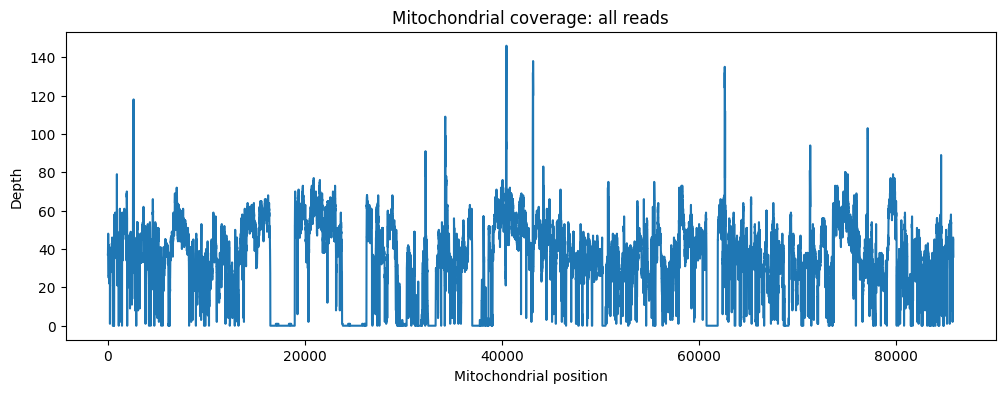

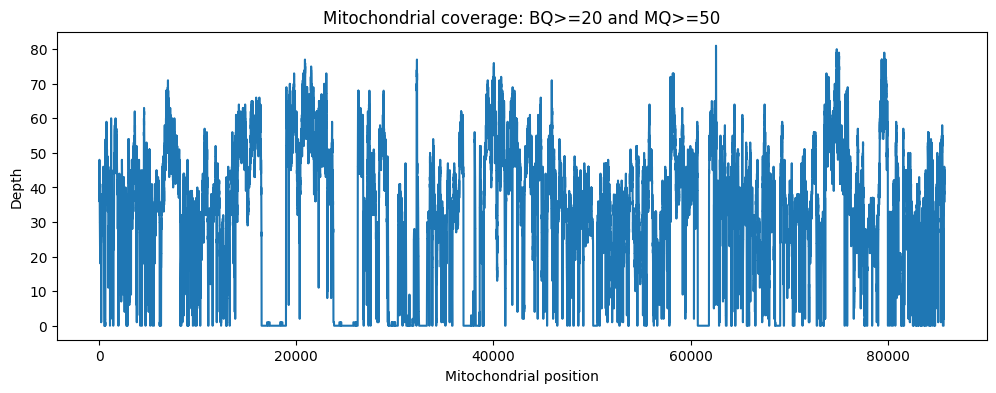

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

def read_depth(path):
    df = pd.read_csv(path, sep="\t", header=None, names=["chrom", "pos", "depth"])
    return df

mito = read_depth(Path(WORKDIR, "mito_coverage"))
mito_q = read_depth(Path(WORKDIR, "mito_coverage_bq20_mq50"))

summary = pd.DataFrame([
    {
        "file": "mito_coverage",
        "mean_depth": mito["depth"].mean(),
        "positions_depth_0": int((mito["depth"] == 0).sum()),
        "positions_depth_ge_4": int((mito["depth"] >= 4).sum()),
    },
    {
        "file": "mito_coverage_bq20_mq50",
        "mean_depth": mito_q["depth"].mean(),
        "positions_depth_0": int((mito_q["depth"] == 0).sum()),
        "positions_depth_ge_4": int((mito_q["depth"] >= 4).sum()),
    },
])
display(summary)

plt.figure(figsize=(12, 4))
plt.plot(mito["pos"], mito["depth"], label="all reads")
plt.xlabel("Mitochondrial position")
plt.ylabel("Depth")
plt.title("Mitochondrial coverage: all reads")
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(mito_q["pos"], mito_q["depth"], label="BQ>=20, MQ>=50")
plt.xlabel("Mitochondrial position")
plt.ylabel("Depth")
plt.title("Mitochondrial coverage: BQ>=20 and MQ>=50")
plt.show()


### 4.6 Extract mitochondrial alignments for visualisation


In [ ]:
%%bash
set -euo pipefail
export PATH="/content/bioinfo_env/bin:/content/bin:$PATH"
cd "$WORKDIR"

samtools view -bh -o mito.bam library_final.bam Mito
samtools index mito.bam

ls -lh mito.bam mito.bam.bai
samtools idxstats library_final.bam | head


-rw-r--r-- 1 root root 2.4M Apr 28 20:57 mito.bam
-rw-r--r-- 1 root root  456 Apr 28 20:57 mito.bam.bai
I	230218	7570	32
II	813184	26805	34
III	316620	11285	27
IV	1531933	50172	49
IX	439888	14897	37
Mito	85779	33388	301
V	576874	20006	78
VI	270161	9450	20
VII	1090940	35606	51
VIII	562643	17955	54


### 4.7 Visualise BAM in the notebook with igv-notebook

Desktop IGV cannot be launched inside Colab in the same way as on the original Xubuntu VM. Instead, this notebook uses `igv-notebook`, which embeds an IGV.js browser.

If the panel does not render the first time, rerun the cell. Colab sometimes requires `igv_notebook.init()` in the same cell as the browser display.


In [ ]:
import sys
import subprocess
from pathlib import Path

try:
    import igv_notebook
except ModuleNotFoundError:
    print("Installing igv-notebook into the active Colab Python kernel...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "igv-notebook"])
    import igv_notebook

igv_notebook.init()

ref_fa = Path(WORKDIR, "Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa")
ref_fai = Path(str(ref_fa) + ".fai")
bam = Path(WORKDIR, "mito.bam")
bai = Path(WORKDIR, "mito.bam.bai")

igv_browser = igv_notebook.Browser({
    "reference": {
        "id": "Saccharomyces_cerevisiae_EF4_68",
        "name": "Saccharomyces cerevisiae EF4.68",
        "fastaPath": str(ref_fa),
        "indexPath": str(ref_fai),
    },
    "locus": "Mito:1-5000",
    "tracks": [
        {
            "name": "mito.bam",
            "type": "alignment",
            "format": "bam",
            "path": str(bam),
            "indexPath": str(bai),
            "height": 500,
        }
    ],
})


Installing igv-notebook into the active Colab Python kernel...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Optional extension: BQSR command template

These commands are included for reference only. Do **not** run them unless you have a suitable known-sites VCF for *S. cerevisiae* and enough compute time.

```bash
gatk BaseRecalibrator \
  -R Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa \
  -I library_final.bam \
  --known-sites latest_dbsnp_or_known_yeast_sites.vcf \
  -O recal_data.table

gatk ApplyBQSR \
  -R Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa \
  -I library_final.bam \
  --bqsr-recal-file recal_data.table \
  -O library_BQSR.bam
```


## Practical 5: Variant calling, comparison and filtering

### Learning objectives

By the end of this section you should be able to:

- call variants with GATK HaplotypeCaller
- call variants with FreeBayes
- extract SNPs with GATK SelectVariants
- compare VCF files with VCFtools
- filter variants by depth and quality
- inspect variants in an IGV-style notebook browser


### 5.1 Confirm input files

Variant calling needs the refined BAM, BAM index, reference FASTA, FASTA index and sequence dictionary in the same working directory.


In [ ]:
%%bash
set -euo pipefail
cd "$WORKDIR"

echo "Variant-calling inputs:"
ls -lh \
  library_final.bam \
  library_final.bam.bai \
  Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa \
  Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa.fai \
  Saccharomyces_cerevisiae.EF4.68.dna.toplevel.dict


Variant-calling inputs:
-rw-r--r-- 1 root root  41M Apr 28 20:56 library_final.bam
-rw-r--r-- 1 root root  11K Apr 28 20:56 library_final.bam.bai
-rw-r--r-- 1 root root 2.5K Apr 28 20:52 Saccharomyces_cerevisiae.EF4.68.dna.toplevel.dict
-rw-r--r-- 1 1000 1000  12M Nov  2  2017 Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa
-rw-r--r-- 1 root root  415 Apr 28 20:51 Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa.fai


Question to answer:

- **Q1.** Are the reference index and dictionary in the same directory as the reference FASTA?


### 5.2 Call variants on chromosome I with GATK HaplotypeCaller

In this reference, the first chromosome is named `I`, not `1`.


In [ ]:
%%bash
set -euo pipefail
export PATH="/content/bioinfo_env/bin:/content/bin:$PATH"
cd "$WORKDIR"

REF="Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa"

gatk HaplotypeCaller \
  -R "$REF" \
  -I library_final.bam \
  -L I \
  -O gatk_variants_raw_I.vcf

gatk HaplotypeCaller \
  -R "$REF" \
  -I library_final.bam \
  -L I \
  -mbq 20 \
  --minimum-mapping-quality 50 \
  -O gatk_variants_raw_I_bq20_mq50.vcf

echo "Variant counts excluding header lines:"
for f in gatk_variants_raw_I.vcf gatk_variants_raw_I_bq20_mq50.vcf; do
  printf "%-40s " "$f"
  grep -vc '^#' "$f"
done


Variant counts excluding header lines:
gatk_variants_raw_I.vcf                  1536
gatk_variants_raw_I_bq20_mq50.vcf        1231


Using GATK jar /content/bioinfo_env/share/gatk4-4.6.2.0-0/gatk-package-4.6.2.0-local.jar
Running:
    java -Dsamjdk.use_async_io_read_samtools=false -Dsamjdk.use_async_io_write_samtools=true -Dsamjdk.use_async_io_write_tribble=false -Dsamjdk.compression_level=2 -jar /content/bioinfo_env/share/gatk4-4.6.2.0-0/gatk-package-4.6.2.0-local.jar HaplotypeCaller -R Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa -I library_final.bam -L I -O gatk_variants_raw_I.vcf
21:00:40.400 INFO  NativeLibraryLoader - Loading libgkl_compression.so from jar:file:/content/bioinfo_env/share/gatk4-4.6.2.0-0/gatk-package-4.6.2.0-local.jar!/com/intel/gkl/native/libgkl_compression.so
21:00:40.716 INFO  HaplotypeCaller - ------------------------------------------------------------
21:00:40.723 INFO  HaplotypeCaller - The Genome Analysis Toolkit (GATK) v4.6.2.0
21:00:40.724 INFO  HaplotypeCaller - For support and documentation go to https://software.broadinstitute.org/gatk/
21:00:40.724 INFO  HaplotypeCaller - Execu

Questions to answer:

- **Q2.** Inspect the VCF outputs. What is the first line of the file?
- **Q3.** How many variants were called in each case? Can you explain the difference?


In [ ]:
%%bash
set -euo pipefail
cd "$WORKDIR"

echo "First lines of the raw GATK VCF:"
sed -n '1,20p' gatk_variants_raw_I.vcf

echo
echo "First non-header variants:"
awk '!/^#/ {print; n++; if (n==5) exit}' gatk_variants_raw_I.vcf

First lines of the raw GATK VCF:
##fileformat=VCFv4.2
##FILTER=<ID=LowQual,Description="Low quality">
##FORMAT=<ID=AD,Number=R,Type=Integer,Description="Allelic depths for the ref and alt alleles in the order listed">
##FORMAT=<ID=DP,Number=1,Type=Integer,Description="Approximate read depth (reads with MQ=255 or with bad mates are filtered)">
##FORMAT=<ID=GQ,Number=1,Type=Integer,Description="Genotype Quality">
##FORMAT=<ID=GT,Number=1,Type=String,Description="Genotype">
##FORMAT=<ID=PL,Number=G,Type=Integer,Description="Normalized, Phred-scaled likelihoods for genotypes as defined in the VCF specification">
##GATKCommandLine=<ID=HaplotypeCaller,CommandLine="HaplotypeCaller --output gatk_variants_raw_I.vcf --intervals I --input library_final.bam --reference Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa --use-posteriors-to-calculate-qual false --dont-use-dragstr-priors false --use-new-qual-calculator true --annotate-with-num-discovered-alleles false --heterozygosity 0.001 --indel-hete

### 5.3 Extract SNPs from the GATK VCF files


In [ ]:
%%bash
set -euo pipefail
export PATH="/content/bioinfo_env/bin:/content/bin:$PATH"
cd "$WORKDIR"

REF="Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa"

gatk SelectVariants \
  -R "$REF" \
  --variant gatk_variants_raw_I.vcf \
  -O gatk_variants_raw_I_SNP.vcf \
  --select-type SNP

gatk SelectVariants \
  -R "$REF" \
  --variant gatk_variants_raw_I_bq20_mq50.vcf \
  -O gatk_variants_raw_I_bq20_mq50_SNP.vcf \
  --select-type SNP

echo "Total variants and SNP-only counts:"
for f in gatk_variants_raw_I.vcf gatk_variants_raw_I_SNP.vcf gatk_variants_raw_I_bq20_mq50.vcf gatk_variants_raw_I_bq20_mq50_SNP.vcf; do
  printf "%-45s " "$f"
  grep -vc '^#' "$f"
done


Total variants and SNP-only counts:
gatk_variants_raw_I.vcf                       1536
gatk_variants_raw_I_SNP.vcf                   1390
gatk_variants_raw_I_bq20_mq50.vcf             1231
gatk_variants_raw_I_bq20_mq50_SNP.vcf         1135


Using GATK jar /content/bioinfo_env/share/gatk4-4.6.2.0-0/gatk-package-4.6.2.0-local.jar
Running:
    java -Dsamjdk.use_async_io_read_samtools=false -Dsamjdk.use_async_io_write_samtools=true -Dsamjdk.use_async_io_write_tribble=false -Dsamjdk.compression_level=2 -jar /content/bioinfo_env/share/gatk4-4.6.2.0-0/gatk-package-4.6.2.0-local.jar SelectVariants -R Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa --variant gatk_variants_raw_I.vcf -O gatk_variants_raw_I_SNP.vcf --select-type SNP
21:03:55.296 INFO  NativeLibraryLoader - Loading libgkl_compression.so from jar:file:/content/bioinfo_env/share/gatk4-4.6.2.0-0/gatk-package-4.6.2.0-local.jar!/com/intel/gkl/native/libgkl_compression.so
21:03:55.734 INFO  SelectVariants - ------------------------------------------------------------
21:03:55.746 INFO  SelectVariants - The Genome Analysis Toolkit (GATK) v4.6.2.0
21:03:55.747 INFO  SelectVariants - For support and documentation go to https://software.broadinstitute.org/gatk/
21:03:55.748 INF

Question to answer:

- **Q4.** How many INDELs were called in each case? Did the BQ20/MQ50 filter change this?

The cell below calculates `INDEL or non-SNP count = total variants - SNP variants`.


In [ ]:
from pathlib import Path
import pandas as pd

def count_vcf_records(path):
    with open(path) as fh:
        return sum(1 for line in fh if not line.startswith("#"))

counts = []
pairs = [
    ("GATK raw", "gatk_variants_raw_I.vcf", "gatk_variants_raw_I_SNP.vcf"),
    ("GATK BQ20/MQ50", "gatk_variants_raw_I_bq20_mq50.vcf", "gatk_variants_raw_I_bq20_mq50_SNP.vcf"),
]
for label, total_vcf, snp_vcf in pairs:
    total = count_vcf_records(Path(WORKDIR, total_vcf))
    snps = count_vcf_records(Path(WORKDIR, snp_vcf))
    counts.append({"callset": label, "total_records": total, "SNP_records": snps, "non_SNP_records": total - snps})

display(pd.DataFrame(counts))


,callset,total_records,SNP_records,non_SNP_records
0,GATK raw,1536,1390,146
1,GATK BQ20/MQ50,1231,1135,96


### 5.4 Call variants with FreeBayes

The FreeBayes command uses minimum base quality 20 and minimum mapping quality 50 to match the filtered GATK run.

Question to answer:

- **Q5.** Check the FreeBayes manual. Why was the `-u` option used in the original practical, and why is it not necessarily best practice?


In [ ]:
%%bash
set -euo pipefail
export PATH="/content/bioinfo_env/bin:/content/bin:$PATH"
cd "$WORKDIR"

REF="Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa"

freebayes \
  -q 20 \
  -m 50 \
  -u \
  -f "$REF" \
  -r I \
  library_final.bam \
  > freebayes_variants_raw_I_bq20_mq50.vcf

gatk SelectVariants \
  -R "$REF" \
  --variant freebayes_variants_raw_I_bq20_mq50.vcf \
  -O freebayes_variants_raw_I_bq20_mq50_SNP.vcf \
  --select-type SNP

echo "FreeBayes total and SNP-only counts:"
for f in freebayes_variants_raw_I_bq20_mq50.vcf freebayes_variants_raw_I_bq20_mq50_SNP.vcf; do
  printf "%-50s " "$f"
  grep -vc '^#' "$f"
done


FreeBayes total and SNP-only counts:
freebayes_variants_raw_I_bq20_mq50.vcf             1127
freebayes_variants_raw_I_bq20_mq50_SNP.vcf         1056


Using GATK jar /content/bioinfo_env/share/gatk4-4.6.2.0-0/gatk-package-4.6.2.0-local.jar
Running:
    java -Dsamjdk.use_async_io_read_samtools=false -Dsamjdk.use_async_io_write_samtools=true -Dsamjdk.use_async_io_write_tribble=false -Dsamjdk.compression_level=2 -jar /content/bioinfo_env/share/gatk4-4.6.2.0-0/gatk-package-4.6.2.0-local.jar SelectVariants -R Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa --variant freebayes_variants_raw_I_bq20_mq50.vcf -O freebayes_variants_raw_I_bq20_mq50_SNP.vcf --select-type SNP
21:04:35.947 INFO  NativeLibraryLoader - Loading libgkl_compression.so from jar:file:/content/bioinfo_env/share/gatk4-4.6.2.0-0/gatk-package-4.6.2.0-local.jar!/com/intel/gkl/native/libgkl_compression.so
21:04:36.371 INFO  SelectVariants - ------------------------------------------------------------
21:04:36.377 INFO  SelectVariants - The Genome Analysis Toolkit (GATK) v4.6.2.0
21:04:36.377 INFO  SelectVariants - For support and documentation go to https://software.broadinstit

### 5.5 Compare GATK and FreeBayes SNP calls with VCFtools

The output column `IN_FILE` indicates whether a SNP was present in both files (`B`), only in the first file (`1`), or only in the second file (`2`).


In [ ]:
%%bash
set -euo pipefail
export PATH="/content/bioinfo_env/bin:/content/bin:$PATH"
cd "$WORKDIR"

vcftools \
  --vcf gatk_variants_raw_I_bq20_mq50_SNP.vcf \
  --diff freebayes_variants_raw_I_bq20_mq50_SNP.vcf \
  --diff-site \
  --out compare \
  > compare.vcftools.log 2>&1

echo "VCFtools outputs:"
ls -lh compare*

echo
echo "VCFtools log:"
cat compare.vcftools.log

echo
echo "Comparison file preview:"
if [ -f compare.diff.sites_in_files ]; then
  echo "---- compare.diff.sites_in_files ----"
  sed -n '1,10p' compare.diff.sites_in_files
else
  echo "No compare.diff.sites_in_files file was created."
fi

echo
echo "Counts from IN_FILE column:"
if [ -f compare.diff.sites_in_files ]; then
  echo "Present in both files:"
  awk 'NR > 1 && $4 == "B" {n++} END {print n+0}' compare.diff.sites_in_files

  echo "Only in GATK file:"
  awk 'NR > 1 && $4 == "1" {n++} END {print n+0}' compare.diff.sites_in_files

  echo "Only in FreeBayes file:"
  awk 'NR > 1 && $4 == "2" {n++} END {print n+0}' compare.diff.sites_in_files
fi

VCFtools outputs:
-rw-r--r-- 1 root root  29K Apr 28 21:07 compare.diff.sites_in_files
-rw-r--r-- 1 root root  23K Apr 28 21:07 compare_filtered.diff.sites_in_files
-rw-r--r-- 1 root root 7.2K Apr 28 21:07 compare.vcftools.log

VCFtools log:

VCFtools - 0.1.17
(C) Adam Auton and Anthony Marcketta 2009

Parameters as interpreted:
	--vcf gatk_variants_raw_I_bq20_mq50_SNP.vcf
	--out compare
	--diff freebayes_variants_raw_I_bq20_mq50_SNP.vcf
	--diff-site

After filtering, kept 1 out of 1 Individuals
Comparing sites in VCF files...
Found 967 sites common to both files.
Found 168 sites only in main file.
Found 89 sites only in second file.
Found 0 non-matching overlapping sites.
After filtering, kept 1135 out of a possible 1135 Sites
Run Time = 0.00 seconds

Comparison file preview:
---- compare.diff.sites_in_files ----
CHROM	POS1	POS2	IN_FILE	REF1	REF2	ALT1	ALT2
I	111	111	B	C	C	T	T
I	136	136	B	G	G	A	A
I	.	262	2	.	A	.	G
I	.	305	2	.	C	.	G
I	.	349	2	.	C	.	T
I	.	367	2	.	A	.	G
I	.	375	2	.	A	.	G


Question to answer:

- **Q6.** How many SNPs are present in both GATK and FreeBayes? How many are present only in one caller?


In [ ]:
from pathlib import Path
import pandas as pd

candidates = [Path(WORKDIR, "compare.diff.sites_in_files"), Path(WORKDIR, "compare.diff.sites")]
compare_file = next((p for p in candidates if p.exists()), None)

if compare_file is None:
    print("No compare.diff.sites* file found.")
else:
    comp = pd.read_csv(compare_file, sep="\t")
    display(comp.head())
    if "IN_FILE" in comp.columns:
        display(comp["IN_FILE"].value_counts().rename_axis("IN_FILE").reset_index(name="count"))
    else:
        print("Columns:", list(comp.columns))


,CHROM,POS1,POS2,IN_FILE,REF1,REF2,ALT1,ALT2
0,I,111,111,B,C,C,T,T
1,I,136,136,B,G,G,A,A
2,I,.,262,2,.,A,.,G
3,I,.,305,2,.,C,.,G
4,I,.,349,2,.,C,.,T


,IN_FILE,count
0,B,967
1,1,168
2,2,89


### 5.6 Visualise variants with igv-notebook

Use the comparison output to choose examples that are present in both callers and examples unique to one caller. Then change the `LOCUS` value below to inspect those positions.


In [ ]:
import igv_notebook
from pathlib import Path

igv_notebook.init()

ref_fa = Path(WORKDIR, "Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa")
ref_fai = Path(str(ref_fa) + ".fai")

# Change this after looking at compare.diff.sites_in_files.
LOCUS = "I:1-50000"

igv_browser = igv_notebook.Browser({
    "reference": {
        "id": "Saccharomyces_cerevisiae_EF4_68",
        "name": "Saccharomyces cerevisiae EF4.68",
        "fastaPath": str(ref_fa),
        "indexPath": str(ref_fai),
    },
    "locus": LOCUS,
    "tracks": [
        {
            "name": "library_final.bam",
            "type": "alignment",
            "format": "bam",
            "path": str(Path(WORKDIR, "library_final.bam")),
            "indexPath": str(Path(WORKDIR, "library_final.bam.bai")),
            "height": 350,
        },
        {
            "name": "GATK SNPs BQ20/MQ50",
            "type": "variant",
            "format": "vcf",
            "path": str(Path(WORKDIR, "gatk_variants_raw_I_bq20_mq50_SNP.vcf")),
        },
        {
            "name": "FreeBayes SNPs BQ20/MQ50",
            "type": "variant",
            "format": "vcf",
            "path": str(Path(WORKDIR, "freebayes_variants_raw_I_bq20_mq50_SNP.vcf")),
        },
    ],
})


Question to answer:

- **Q7.** Explore variants in the embedded IGV browser. What information appears when you click or hover over variants and reads?


### 5.7 Filter SNPs with VCFtools

We apply two filters:

- minimum depth `--minDP 3`
- minimum variant QUAL score `--minQ 20`

Then we remove variants with missing data using `--max-missing 1`.


In [ ]:
%%bash
set -euo pipefail
export PATH="/content/bioinfo_env/bin:/content/bin:$PATH"
cd "$WORKDIR"

# GATK filtered SNPs
vcftools \
  --vcf gatk_variants_raw_I_bq20_mq50_SNP.vcf \
  --minDP 3 \
  --minQ 20 \
  --out gatk_variants_I_flt2 \
  --recode \
  --recode-INFO-all

vcftools \
  --vcf gatk_variants_I_flt2.recode.vcf \
  --max-missing 1 \
  --out gatk_variants_I_flt2_nomissing \
  --recode \
  --recode-INFO-all

# FreeBayes filtered SNPs
vcftools \
  --vcf freebayes_variants_raw_I_bq20_mq50_SNP.vcf \
  --minDP 3 \
  --minQ 20 \
  --out freebayes_variants_I_flt2 \
  --recode \
  --recode-INFO-all

vcftools \
  --vcf freebayes_variants_I_flt2.recode.vcf \
  --max-missing 1 \
  --out freebayes_variants_I_flt2_nomissing \
  --recode \
  --recode-INFO-all

echo "Filtered VCF counts:"
for f in \
  gatk_variants_raw_I_bq20_mq50_SNP.vcf \
  gatk_variants_I_flt2.recode.vcf \
  gatk_variants_I_flt2_nomissing.recode.vcf \
  freebayes_variants_raw_I_bq20_mq50_SNP.vcf \
  freebayes_variants_I_flt2.recode.vcf \
  freebayes_variants_I_flt2_nomissing.recode.vcf
do
  printf "%-55s " "$f"
  grep -vc '^#' "$f"
done


Filtered VCF counts:
gatk_variants_raw_I_bq20_mq50_SNP.vcf                   1135
gatk_variants_I_flt2.recode.vcf                         1135
gatk_variants_I_flt2_nomissing.recode.vcf               901
freebayes_variants_raw_I_bq20_mq50_SNP.vcf              1056
freebayes_variants_I_flt2.recode.vcf                    1022
freebayes_variants_I_flt2_nomissing.recode.vcf          817



VCFtools - 0.1.17
(C) Adam Auton and Anthony Marcketta 2009

Parameters as interpreted:
	--vcf gatk_variants_raw_I_bq20_mq50_SNP.vcf
	--recode-INFO-all
	--minDP 3
	--minQ 20
	--out gatk_variants_I_flt2
	--recode

After filtering, kept 1 out of 1 Individuals
Outputting VCF file...
After filtering, kept 1135 out of a possible 1135 Sites
Run Time = 0.00 seconds

VCFtools - 0.1.17
(C) Adam Auton and Anthony Marcketta 2009

Parameters as interpreted:
	--vcf gatk_variants_I_flt2.recode.vcf
	--recode-INFO-all
	--max-missing 1
	--out gatk_variants_I_flt2_nomissing
	--recode

After filtering, kept 1 out of 1 Individuals
Outputting VCF file...
After filtering, kept 901 out of a possible 1135 Sites
Run Time = 0.00 seconds

VCFtools - 0.1.17
(C) Adam Auton and Anthony Marcketta 2009

Parameters as interpreted:
	--vcf freebayes_variants_raw_I_bq20_mq50_SNP.vcf
	--recode-INFO-all
	--minDP 3
	--minQ 20
	--out freebayes_variants_I_flt2
	--recode

After filtering, kept 1 out of 1 Individuals
Outputtin

Questions to answer:

- **Q8.** Inspect the first few variants in the filtered output. How did the filtering command behave?
- **Q9.** Why might it be useful to exclude variants with missing data?
- **Q11.** How many SNPs were filtered out for GATK and for FreeBayes?
- **Q12.** How many variants passed the filters?


In [ ]:
from pathlib import Path
import pandas as pd

vcfs = {
    "GATK raw SNP": "gatk_variants_raw_I_bq20_mq50_SNP.vcf",
    "GATK minDP3 minQ20": "gatk_variants_I_flt2.recode.vcf",
    "GATK no missing": "gatk_variants_I_flt2_nomissing.recode.vcf",
    "FreeBayes raw SNP": "freebayes_variants_raw_I_bq20_mq50_SNP.vcf",
    "FreeBayes minDP3 minQ20": "freebayes_variants_I_flt2.recode.vcf",
    "FreeBayes no missing": "freebayes_variants_I_flt2_nomissing.recode.vcf",
}

rows = []
for label, fname in vcfs.items():
    rows.append({"callset": label, "records": count_vcf_records(Path(WORKDIR, fname))})

df_counts = pd.DataFrame(rows)
display(df_counts)

gatk_raw = df_counts.loc[df_counts.callset == "GATK raw SNP", "records"].iloc[0]
gatk_final = df_counts.loc[df_counts.callset == "GATK no missing", "records"].iloc[0]
fb_raw = df_counts.loc[df_counts.callset == "FreeBayes raw SNP", "records"].iloc[0]
fb_final = df_counts.loc[df_counts.callset == "FreeBayes no missing", "records"].iloc[0]

display(pd.DataFrame([
    {"caller": "GATK", "raw_SNPs": gatk_raw, "passed_filters": gatk_final, "filtered_out": gatk_raw - gatk_final},
    {"caller": "FreeBayes", "raw_SNPs": fb_raw, "passed_filters": fb_final, "filtered_out": fb_raw - fb_final},
]))


,callset,records
0,GATK raw SNP,1135
1,GATK minDP3 minQ20,1135
2,GATK no missing,901
3,FreeBayes raw SNP,1056
4,FreeBayes minDP3 minQ20,1022
5,FreeBayes no missing,817


,caller,raw_SNPs,passed_filters,filtered_out
0,GATK,1135,901,234
1,FreeBayes,1056,817,239


### 5.8 Compare filtered GATK and FreeBayes calls


In [ ]:
%%bash
set -euo pipefail
export PATH="/content/bioinfo_env/bin:/content/bin:$PATH"
cd "$WORKDIR"

vcftools \
  --vcf gatk_variants_I_flt2_nomissing.recode.vcf \
  --diff freebayes_variants_I_flt2_nomissing.recode.vcf \
  --diff-site \
  --out compare_filtered \
  > compare_filtered.vcftools.log 2>&1

echo "Filtered comparison outputs:"
ls -lh compare_filtered*

echo
echo "VCFtools log:"
cat compare_filtered.vcftools.log

echo
echo "Comparison file preview:"
if [ -f compare_filtered.diff.sites_in_files ]; then
  echo "---- compare_filtered.diff.sites_in_files ----"
  sed -n '1,10p' compare_filtered.diff.sites_in_files
else
  echo "No compare_filtered.diff.sites_in_files file was created."
fi

echo
echo "Counts from IN_FILE column:"
if [ -f compare_filtered.diff.sites_in_files ]; then
  echo "Present in both files:"
  awk 'NR > 1 && $4 == "B" {n++} END {print n+0}' compare_filtered.diff.sites_in_files

  echo "Only in GATK file:"
  awk 'NR > 1 && $4 == "1" {n++} END {print n+0}' compare_filtered.diff.sites_in_files

  echo "Only in FreeBayes file:"
  awk 'NR > 1 && $4 == "2" {n++} END {print n+0}' compare_filtered.diff.sites_in_files
fi

Filtered comparison outputs:
-rw-r--r-- 1 root root  23K Apr 28 21:09 compare_filtered.diff.sites_in_files
-rw-r--r-- 1 root root 7.2K Apr 28 21:09 compare_filtered.vcftools.log

VCFtools log:

VCFtools - 0.1.17
(C) Adam Auton and Anthony Marcketta 2009

Parameters as interpreted:
	--vcf gatk_variants_I_flt2_nomissing.recode.vcf
	--out compare_filtered
	--diff freebayes_variants_I_flt2_nomissing.recode.vcf
	--diff-site

After filtering, kept 1 out of 1 Individuals
Comparing sites in VCF files...
Found 757 sites common to both files.
Found 144 sites only in main file.
Found 60 sites only in second file.
Found 0 non-matching overlapping sites.
After filtering, kept 901 out of a possible 901 Sites
Run Time = 0.00 seconds

Comparison file preview:
---- compare_filtered.diff.sites_in_files ----
CHROM	POS1	POS2	IN_FILE	REF1	REF2	ALT1	ALT2
I	.	111	2	.	C	.	T
I	136	136	B	G	G	A	A
I	.	262	2	.	A	.	G
I	.	349	2	.	C	.	T
I	1025	1025	B	C	C	T	T
I	1035	.	1	A	.	T	.
I	1074	1074	B	C	C	A	A
I	1084	1084	B	A	A	

Question to answer:

- **Q13.** Did filtering affect the number of SNPs common to both callers or unique to one caller?


In [ ]:
from pathlib import Path
import pandas as pd

candidates = [Path(WORKDIR, "compare_filtered.diff.sites_in_files"), Path(WORKDIR, "compare_filtered.diff.sites")]
compare_filtered_file = next((p for p in candidates if p.exists()), None)

if compare_filtered_file is None:
    print("No compare_filtered.diff.sites* file found.")
else:
    comp_f = pd.read_csv(compare_filtered_file, sep="\t")
    display(comp_f.head())
    if "IN_FILE" in comp_f.columns:
        display(comp_f["IN_FILE"].value_counts().rename_axis("IN_FILE").reset_index(name="count"))
    else:
        print("Columns:", list(comp_f.columns))


,CHROM,POS1,POS2,IN_FILE,REF1,REF2,ALT1,ALT2
0,I,.,111,2,.,C,.,T
1,I,136,136,B,G,G,A,A
2,I,.,262,2,.,A,.,G
3,I,.,349,2,.,C,.,T
4,I,1025,1025,B,C,C,T,T


,IN_FILE,count
0,B,757
1,1,144
2,2,60


### 5.9 Visualise filtered variants

Change `LOCUS` to a position from `compare_filtered.diff.sites_in_files` and inspect the filtered GATK and FreeBayes calls.


In [ ]:
import sys
import subprocess
from pathlib import Path

try:
    import igv_notebook
except ModuleNotFoundError:
    print("Installing igv-notebook into the active Colab Python kernel...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "igv-notebook"])
    import igv_notebook

igv_notebook.init()

ref_fa = Path(WORKDIR, "Saccharomyces_cerevisiae.EF4.68.dna.toplevel.fa")
ref_fai = Path(str(ref_fa) + ".fai")

# Change this to a variant position you want to inspect.
LOCUS = "I:1-50000"

igv_browser = igv_notebook.Browser({
    "reference": {
        "id": "Saccharomyces_cerevisiae_EF4_68",
        "name": "Saccharomyces cerevisiae EF4.68",
        "fastaPath": str(ref_fa),
        "indexPath": str(ref_fai),
    },
    "locus": LOCUS,
    "tracks": [
        {
            "name": "library_final.bam",
            "type": "alignment",
            "format": "bam",
            "path": str(Path(WORKDIR, "library_final.bam")),
            "indexPath": str(Path(WORKDIR, "library_final.bam.bai")),
            "height": 350,
        },
        {
            "name": "GATK filtered SNPs",
            "type": "variant",
            "format": "vcf",
            "path": str(Path(WORKDIR, "gatk_variants_I_flt2_nomissing.recode.vcf")),
        },
        {
            "name": "FreeBayes filtered SNPs",
            "type": "variant",
            "format": "vcf",
            "path": str(Path(WORKDIR, "freebayes_variants_I_flt2_nomissing.recode.vcf")),
        },
    ],
})


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Going further: QUAL > 100 variants

This exercise uses `grep` and `awk` to extract variants with QUAL scores above 100.


In [ ]:
%%bash
set -euo pipefail
cd "$WORKDIR"

grep -v '^#' gatk_variants_I_flt2_nomissing.recode.vcf \
  | awk '{if ($6 > 100) print}' \
  > gatk_QUAL_100_variants.tsv

grep -v '^#' freebayes_variants_I_flt2_nomissing.recode.vcf \
  | awk '{if ($6 > 100) print}' \
  > freebayes_QUAL_100_variants.tsv

echo "Variants with QUAL > 100:"
for f in gatk_QUAL_100_variants.tsv freebayes_QUAL_100_variants.tsv; do
  printf "%-35s " "$f"
  wc -l < "$f"
done


Variants with QUAL > 100:
gatk_QUAL_100_variants.tsv          755
freebayes_QUAL_100_variants.tsv     477


Question to answer:

- **Q14.** How many SNPs have QUAL scores above 100 in the GATK and FreeBayes filtered files? Do you think there is any significance to the result?


## Save or download outputs

Colab storage is temporary. Use the cell below to package the key outputs from the practicals into a compressed archive.


In [ ]:
%%bash
set -euo pipefail
cd "$WORKDIR"

tar -czf /content/GMO4_colab_outputs.tar.gz \
  fastqc_raw fastqc_trimmed \
  multiqc_raw.html multiqc_raw_vs_trimmed.html \
  lane1_flagstat.txt lane2_flagstat.txt \
  library_flagstat.txt library_final_flagstat.txt \
  dupl_metrics.txt qualimap_report \
  mito_coverage mito_coverage_bq20_mq50 \
  *.vcf *.log compare* \
  gatk_QUAL_100_variants.tsv freebayes_QUAL_100_variants.tsv \
  2>/dev/null || true

ls -lh /content/GMO4_colab_outputs.tar.gz


-rw-r--r-- 1 root root 5.4M Apr 28 21:09 /content/GMO4_colab_outputs.tar.gz


In [ ]:
# Uncomment to download the results archive to your computer.
# from google.colab import files
# files.download("/content/GMO4_colab_outputs.tar.gz")


## Summary

You have reproduced the workflow across the four practicals:

1. raw-read QC
2. adapter removal and quality trimming
3. reference indexing
4. BWA alignment
5. SAM/BAM conversion, sorting, indexing and merging
6. duplicate marking
7. BAM QC and coverage analysis
8. variant calling with GATK and FreeBayes
9. SNP extraction, comparison and filtering
10. notebook-based visualisation of alignments and variants

The same core ideas apply to human clinical sequencing workflows, but human-scale analysis requires substantially more compute, careful data governance and validated clinical pipelines.
